In [259]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import manifold, model_selection, ensemble
%matplotlib inline
py.init_notebook_mode(connected=True)
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.cross_validation import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [260]:
data = pd.read_csv("../data/LionsDen.csv",sep=";",decimal=",")

print("Are there NaN values? ", data.isna().any().any())


data.head()

Are there NaN values?  True


,Unnamed: 0,CUSTOMER_ID,APPLICATION_ID,DEFAULT_FLAG,APPLICATION_DATE,APPLICATION_HOUR,APPLICATION_WEEKDAY,APPLICATION_MONTH,APPLICATION_YEAR,PRODUCT_GROUP,...,DPD,DPD_FALL_IN_12M,BIK_NUM_REQ_TOTAL_LZ3,BIK_NUM_REQ_TOTAL_LZ4_12,BIK_GRP,BIK_ACC_NUM_TOTAL_CLOSE,BIK_ACC_NUM_TOTAL_OPEN,BIK_BAL_TOTAL_OPEN,BIK_OVERDUE_12M_TOTAL_MAX,BIK_OVERDUE_EVER_TOTAL_MAX
0,1,102528122,362318345049,0,2017-05-10,07-24,3,5,2017,CASH LOAN,...,0.0,4.0,2,3,CREDIT HISTORY (FULL DATA),5.0,9.0,19250.0,0.0,0.0
1,2,146634735,635743726807,0,2016-01-09,07-24,7,1,2016,CASH LOAN,...,NaN,8.0,2,2,CREDIT HISTORY (FULL DATA),1.0,2.0,10950.0,0.0,3244.0
2,3,996453767,694627725843,0,2016-07-07,07-24,5,7,2016,OVERDRAFT,...,NaN,1.0,1,0,CREDIT HISTORY (FULL DATA),3.0,1.0,4650.0,67.0,67.0
3,4,816020174,989259535442,0,2016-07-20,07-24,3,7,2016,CASH LOAN,...,0.0,10.0,1,18,CREDIT HISTORY (FULL DATA),7.0,5.0,33300.0,0.0,1.0
4,5,930630805,77906299419,0,2015-06-30,07-24,3,6,2015,CASH LOAN,...,0.0,0.0,3,9,CREDIT HISTORY (PART DATA),13.0,2.0,3100.0,0.0,0.0


In [67]:
data.EMAIL_NAME_SURNAME.value_counts()

LACK OF NAME/SURNAME    28742
NAME AND SURNAME        17949
LACK OF EMAIL           13449
ONLY SURNAME            11334
ONLY NAME                7681
Name: EMAIL_NAME_SURNAME, dtype: int64

In [8]:
print("Is id unique? ",data.CUSTOMER_ID.is_unique)
print("Is application unique? ",data.APPLICATION_ID.is_unique)

Is id unique?  False
Is application unique?  True


In [9]:
data.describe()

,Unnamed: 0,CUSTOMER_ID,APPLICATION_ID,DEFAULT_FLAG,APPLICATION_WEEKDAY,APPLICATION_MONTH,APPLICATION_YEAR,LOAN_PERIOD,CREDIT_AMOUNT,COOP_PERIOD,...,DUE_AMOUNT,DPD,DPD_FALL_IN_12M,BIK_NUM_REQ_TOTAL_LZ3,BIK_NUM_REQ_TOTAL_LZ4_12,BIK_ACC_NUM_TOTAL_CLOSE,BIK_ACC_NUM_TOTAL_OPEN,BIK_BAL_TOTAL_OPEN,BIK_OVERDUE_12M_TOTAL_MAX,BIK_OVERDUE_EVER_TOTAL_MAX
count,79155.000000,7.915500e+04,7.915500e+04,79155.000000,79155.000000,79155.000000,79155.000000,79155.000000,79155.000000,79155.000000,...,65876.000000,65876.000000,71972.000000,79155.000000,79155.000000,74222.000000,74222.000000,7.422200e+04,74222.000000,74222.000000
mean,39578.000000,5.011687e+08,4.994300e+11,0.042410,3.901270,6.807845,2015.938601,41.482774,4667.297075,98.584979,...,7.041563,1.007833,3.437851,2.511515,2.491542,6.885977,3.934777,2.508902e+04,138.406807,572.854356
std,22850.224616,2.879946e+08,2.890948e+11,0.201525,1.757579,3.328680,1.092482,35.390071,6685.304097,64.066750,...,72.581892,18.193063,3.445301,1.821091,2.715710,8.925993,3.395230,4.701492e+04,1492.918659,4628.737114
min,1.000000,8.245000e+03,3.686175e+06,0.000000,1.000000,1.000000,2014.000000,0.000000,200.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,19789.500000,2.530550e+08,2.490771e+11,0.000000,2.000000,4.000000,2015.000000,12.000000,900.000000,49.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,2.000000,3.050000e+03,0.000000,0.000000
50%,39578.000000,5.009870e+08,4.990683e+11,0.000000,4.000000,7.000000,2016.000000,30.000000,2100.000000,86.000000,...,0.000000,0.000000,2.000000,2.000000,2.000000,4.000000,3.000000,1.025000e+04,0.000000,13.000000
75%,59366.500000,7.519408e+08,7.504741e+11,0.000000,5.000000,10.000000,2017.000000,80.000000,4700.000000,135.000000,...,0.000000,0.000000,6.000000,3.000000,4.000000,9.000000,5.000000,2.630000e+04,44.750000,204.000000
max,79155.000000,9.999889e+08,9.999911e+11,1.000000,7.000000,12.000000,2017.000000,96.000000,57000.000000,548.000000,...,11370.000000,949.000000,12.000000,37.000000,52.000000,175.000000,44.000000,1.061300e+06,133067.000000,512783.000000


In [92]:
numeric = data.select_dtypes(include=['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool'])
numeric.head()

,Unnamed: 0,CUSTOMER_ID,APPLICATION_ID,DEFAULT_FLAG,APPLICATION_WEEKDAY,APPLICATION_MONTH,APPLICATION_YEAR,LOAN_PERIOD,CREDIT_AMOUNT,COOP_PERIOD,...,DUE_AMOUNT,DPD,DPD_FALL_IN_12M,BIK_NUM_REQ_TOTAL_LZ3,BIK_NUM_REQ_TOTAL_LZ4_12,BIK_ACC_NUM_TOTAL_CLOSE,BIK_ACC_NUM_TOTAL_OPEN,BIK_BAL_TOTAL_OPEN,BIK_OVERDUE_12M_TOTAL_MAX,BIK_OVERDUE_EVER_TOTAL_MAX
0,1,102528122,362318345049,0,3,5,2017,96,4200,44,...,0.0,0.0,4.0,2,3,5.0,9.0,19250.0,0.0,0.0
1,2,146634735,635743726807,0,7,1,2016,36,11100,52,...,NaN,NaN,8.0,2,2,1.0,2.0,10950.0,0.0,3244.0
2,3,996453767,694627725843,0,5,7,2016,0,800,147,...,NaN,NaN,1.0,1,0,3.0,1.0,4650.0,67.0,67.0
3,4,816020174,989259535442,0,3,7,2016,36,5900,73,...,0.0,0.0,10.0,1,18,7.0,5.0,33300.0,0.0,1.0
4,5,930630805,77906299419,0,3,6,2015,5,1400,82,...,0.0,0.0,0.0,3,9,13.0,2.0,3100.0,0.0,0.0


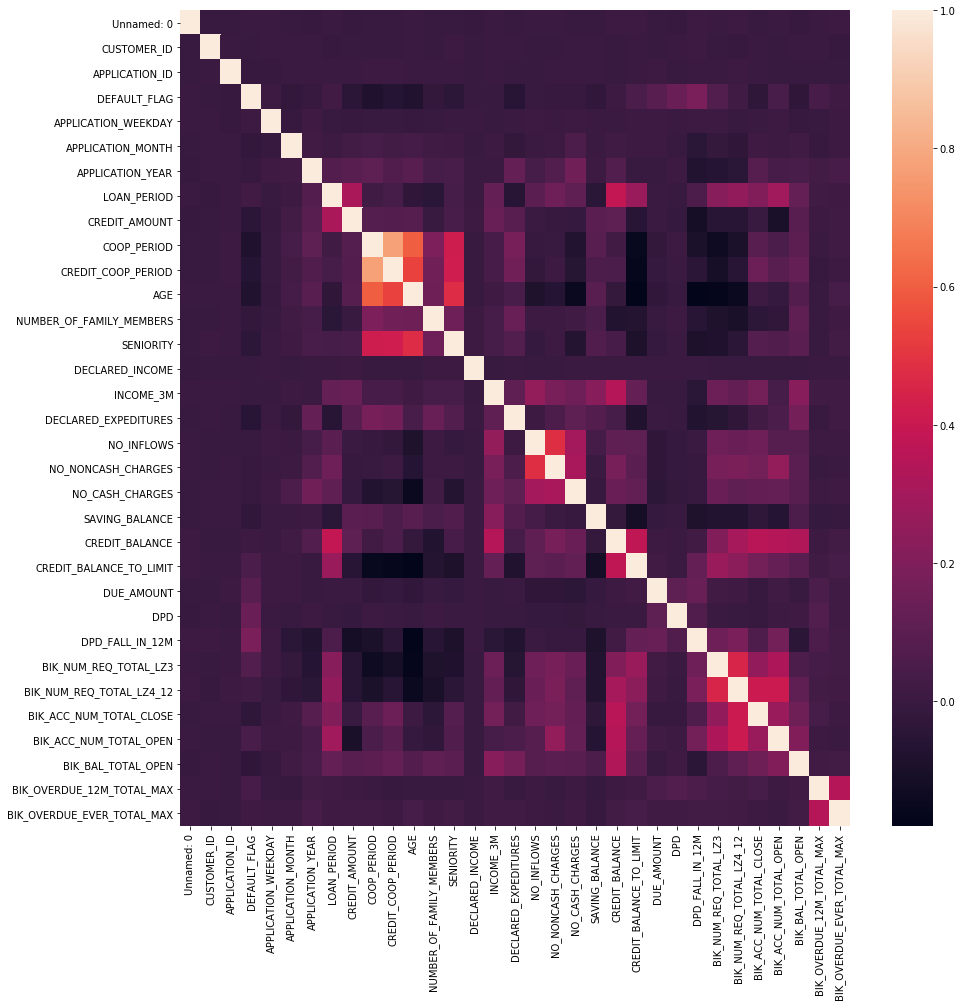

In [93]:
plt.figure(figsize=(15,15))
sns.heatmap(numeric.corr(), )
plt.show()

## Model based on all varaibles

In [23]:
X = numeric.drop('DEFAULT_FLAG', axis=1)
X = X.drop('Unnamed: 0', axis=1)
X = X.drop("CUSTOMER_ID",axis=1)
X = X.drop("APPLICATION_ID",axis=1)
X = X.fillna(X.mean())

y = numeric.DEFAULT_FLAG

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=0)

In [25]:
logit_model=sm.Logit(y_train,X_train)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.149582
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:           DEFAULT_FLAG   No. Observations:                55408
Model:                          Logit   Df Residuals:                    55381
Method:                           MLE   Df Model:                           26
Date:                Wed, 16 May 2018   Pseudo R-squ.:                  0.1429
Time:                        17:22:49   Log-Likelihood:                -8288.0
converged:                       True   LL-Null:                       -9670.0
                                        LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
APPLICATION_WEEKDAY            0.0260      0.012      2.093      0.036     

In [39]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)
print(model.coef_)

[[  9.48242330e-06  -2.57751344e-05   1.39128098e-04   4.98561337e-04
   -3.86972519e-05  -1.66269308e-03  -1.09178630e-03  -2.72645358e-04
   -5.39711130e-06  -7.29455124e-04  -4.69184649e-06   9.67459784e-07
   -6.75967127e-06  -4.88133859e-05  -6.72308190e-05  -3.02192571e-05
    9.91832671e-06   1.77231799e-03   9.35186780e-04   2.44538398e-04
    5.31155248e-05   1.37582871e-05  -1.56262288e-04   5.88610522e-05
   -4.88222189e-06   4.40373613e-04   4.12751499e-06]]


In [40]:
y_preds = model.predict(X_test,)
print(classification_report(y_test, y_preds))

             precision    recall  f1-score   support

          0       0.98      0.57      0.72     22722
          1       0.07      0.73      0.13      1025

avg / total       0.94      0.57      0.69     23747



## ANOVA

In [19]:
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [146]:
anova_lm = ols('DEFAULT_FLAG ~ C(AGE_BANDS)+C(EDUCATION)+C(EMAIL_DOMAIN)+C(EMP_TYPE)+C(MARITAL_STATUS)+C(OWNERSHIP)+ C(BIK_GRP)+C(EMAIL_NAME_SURNAME)+C(PRODUCT_GROUP)', data=data).fit()
table = sm.stats.anova_lm(anova_lm, typ=2) # Type 2 ANOVA DataFrame

print(table)

                            sum_sq       df          F        PR(>F)
C(AGE_BANDS)             14.647574      7.0  52.553648  2.773674e-75
C(EDUCATION)              7.277037      6.0  30.460604  9.713717e-37
C(EMAIL_DOMAIN)           3.692816     17.0   5.455618  1.964547e-12
C(EMP_TYPE)               4.273295      8.0  13.415536  1.394028e-19
C(MARITAL_STATUS)         1.740621      5.0   8.743182  2.659010e-08
C(OWNERSHIP)              0.492406      7.0   1.766692  8.913923e-02
C(BIK_GRP)                4.095492      2.0  51.429383  4.775436e-23
C(EMAIL_NAME_SURNAME)     0.975548      4.0   6.125248  6.347592e-05
C(PRODUCT_GROUP)          0.863604      2.0  10.844757  1.953564e-05
Residual               3149.378189  79097.0        NaN           NaN


In [79]:
anova_lm = ols('DEFAULT_FLAG ~ C(AGE_BANDS)+C(EMP_TYPE)+C(MARITAL_STATUS)+ C(BIK_GRP)+C(EMAIL_NAME_SURNAME)+C(PRODUCT_GROUP) ', data=data).fit()
table = sm.stats.anova_lm(anova_lm, typ=2) # Type 2 ANOVA DataFrame

print(table)

                            sum_sq       df          F         PR(>F)
C(AGE_BANDS)             20.229556      7.0  72.397686  6.159140e-105
C(EMP_TYPE)               4.400304      8.0  13.779362   3.525879e-20
C(MARITAL_STATUS)         1.950691      5.0   9.773604   2.377233e-09
C(BIK_GRP)                4.356224      2.0  54.565311   2.084075e-24
C(EMAIL_NAME_SURNAME)     1.015987      4.0   6.363037   4.087353e-05
C(PRODUCT_GROUP)          0.604130      2.0   7.567227   5.174988e-04
Residual               3158.514156  79126.0        NaN            NaN


### NEW DATA - Binary data

In [304]:
new_data = pd.DataFrame({"DEFAULT_FLAG": data.DEFAULT_FLAG})

In [305]:
NY_vars  = ['MAIL_ADDR_SAME_AS_RESIDENTIAL',
 'MARKETING_CONSENT',
 #'REMUNERATION_PAID_BY_CASH',
 'SPOUSE_PROPERTY_STATUS',
 'REMUNERATION_PAID_TO_ING',
 'CUSTOMER_RUNNING_A_BUSINESS']

In [306]:
for var in NY_vars:
    new_data[var] = 0
    new_data.loc[data[var]=="Y",var] = 1
    

In [307]:
categorical_vars = ['AGE_BANDS','EMP_TYPE','MARITAL_STATUS', 'BIK_GRP','EMAIL_NAME_SURNAME','PRODUCT_GROUP']

In [308]:
for var in categorical_vars:
    new_data = pd.concat([new_data, pd.get_dummies(data[var])], axis=1)

In [309]:
new_data["MISSING_INTERNAL_DATA"] = (data.INCOME_3M.isna()).astype('int')

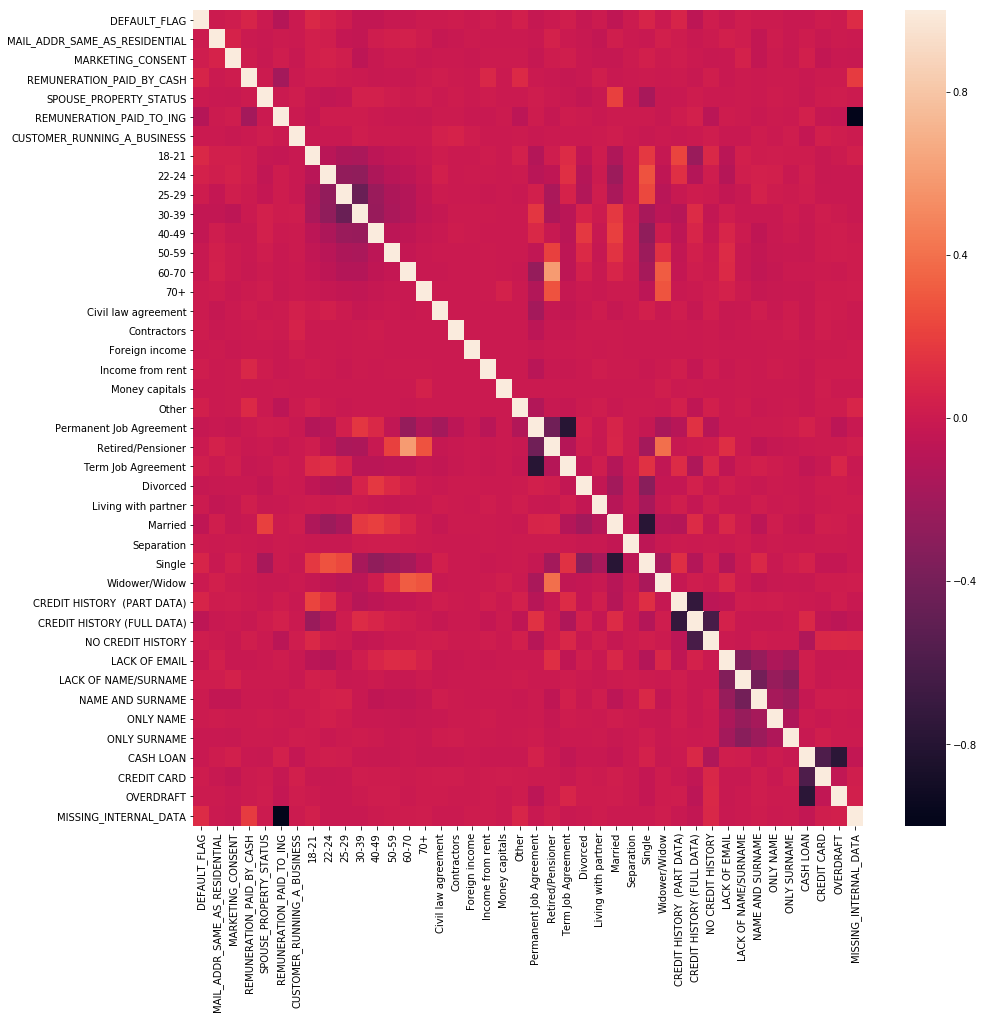

In [291]:
plt.figure(figsize=(15,15))
sns.heatmap(new_data.corr(), )
plt.show()

In [261]:
X = new_data.drop('DEFAULT_FLAG', axis=1)

# X = X.drop("ONLY NAME", axis=1)
# X = X.drop("Other",axis=1)
# X = X.drop("70+",axis=1)
# X = X.drop("OVERDRAFT", axis=1)


y = numeric.DEFAULT_FLAG

In [292]:
X_train, X_test_t, y_train, y_test_t = train_test_split(X,y, test_size=0.3, random_state=0)

In [209]:
from sklearn.datasets import make_classification
from sklearn.ensemble import ExtraTreesClassifier



# Build a forest and compute the feature importances
forest = ExtraTreesClassifier(n_estimators=250,
                              random_state=0)

forest.fit(X_train, y_train)
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]


1. feature MAIL_ADDR_SAME_AS_RESIDENTIAL (0.095456)
2. feature MARKETING_CONSENT (0.068737)
3. feature REMUNERATION_PAID_BY_CASH (0.059264)
4. feature MISSING_INTERNAL_DATA (0.038366)
5. feature 18-21 (0.037996)
6. feature LACK OF NAME/SURNAME (0.036965)
7. feature NAME AND SURNAME (0.036825)
8. feature REMUNERATION_PAID_TO_ING (0.035589)
9. feature CASH LOAN (0.032613)
10. feature ONLY NAME (0.032251)
11. feature ONLY SURNAME (0.031487)
12. feature CREDIT HISTORY (FULL DATA) (0.030875)
13. feature Permanent Job Agreement (0.030804)
14. feature Term Job Agreement (0.027723)
15. feature OVERDRAFT (0.027545)
16. feature LACK OF EMAIL (0.027474)
17. feature Single (0.027424)
18. feature 22-24 (0.024366)
19. feature CREDIT CARD (0.024037)
20. feature 25-29 (0.023270)
21. feature NO CREDIT HISTORY (0.022497)
22. feature CREDIT HISTORY  (PART DATA) (0.022460)
23. feature Married (0.022223)
24. feature Retired/Pensioner (0.022133)
25. feature 30-39 (0.021979)
26. feature Other (0.015728)
27. 

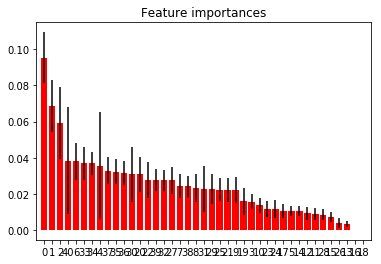

In [210]:
for f in range(X.shape[1]):
    print("%d. feature %s (%f)" % (f + 1, X.columns[indices[f]], importances[indices[f]]))

# Plot the feature importances of the forest
plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices],
       color="r", yerr=std[indices], align="center")
plt.xticks(range(X.shape[1]), indices)
plt.xlim([-1, X.shape[1]])
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape

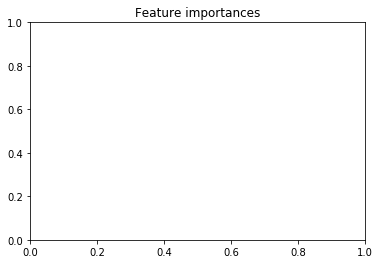

In [239]:
plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices],
       color="r", yerr=std[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices])
plt.xlim([-1, X.shape[1]])
plt.show()

In [293]:
X = new_data.drop('DEFAULT_FLAG', axis=1)

X = X.drop("ONLY NAME", axis=1)
X = X.drop("Other",axis=1)
X = X.drop("70+",axis=1)
X = X.drop("Married",axis=1)
X = X.drop("OVERDRAFT", axis=1)


y = numeric.DEFAULT_FLAG

In [294]:
X_train, X_test_2, y_train, y_test_2 = train_test_split(X,y, test_size=0.3, random_state=0)

In [295]:
logit_model=sm.Logit(y_train,X_train)
result=logit_model.fit()
print(result.summary())

         Current function value: 0.164210
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:           DEFAULT_FLAG   No. Observations:                55408
Model:                          Logit   Df Residuals:                    55373
Method:                           MLE   Df Model:                           34
Date:                Wed, 16 May 2018   Pseudo R-squ.:                 0.05909
Time:                        21:14:18   Log-Likelihood:                -9098.6
converged:                      False   LL-Null:                       -9670.0
                                        LLR p-value:                4.314e-218
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
MAIL_ADDR_SAME_AS_RESIDENTIAL    -0.0043      0.052     -0.081      0.935      -0.107       0.099
MARKETIN

/Users/tomasz/anaconda/envs/python36/lib/python3.6/site-packages/statsmodels/base/model.py:496: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [296]:
model2 = LogisticRegression(class_weight="balanced")
model2.fit(X_train, y_train)
print(model.coef_)

[[  9.48242330e-06  -2.57751344e-05   1.39128098e-04   4.98561337e-04
   -3.86972519e-05  -1.66269308e-03  -1.09178630e-03  -2.72645358e-04
   -5.39711130e-06  -7.29455124e-04  -4.69184649e-06   9.67459784e-07
   -6.75967127e-06  -4.88133859e-05  -6.72308190e-05  -3.02192571e-05
    9.91832671e-06   1.77231799e-03   9.35186780e-04   2.44538398e-04
    5.31155248e-05   1.37582871e-05  -1.56262288e-04   5.88610522e-05
   -4.88222189e-06   4.40373613e-04   4.12751499e-06]]


In [297]:
y_preds = model2.predict(X_test_2,)
print(classification_report(y_test_2, y_preds))

             precision    recall  f1-score   support

          0       0.97      0.65      0.78     22722
          1       0.07      0.60      0.13      1025

avg / total       0.93      0.64      0.75     23747



## All  data combined

In [310]:
 numeric_vars=['CREDIT_AMOUNT', 'COOP_PERIOD',
       'INCOME_3M', 'NO_INFLOWS', 'NO_NONCASH_CHARGES', 'NO_CASH_CHARGES',
       'SAVING_BALANCE', 'CREDIT_BALANCE', 'DUE_AMOUNT',
       'DPD_FALL_IN_12M', 
       'BIK_ACC_NUM_TOTAL_CLOSE', 'BIK_ACC_NUM_TOTAL_OPEN',
       'BIK_BAL_TOTAL_OPEN', 'BIK_OVERDUE_12M_TOTAL_MAX',
       'BIK_OVERDUE_EVER_TOTAL_MAX']

In [311]:
for var in numeric_vars:
    new_data[var] = data[var]
    

In [312]:
new_data["BIK_NUM_REQ_TOTAL"] = data['BIK_NUM_REQ_TOTAL_LZ3']+ data['BIK_NUM_REQ_TOTAL_LZ4_12']

In [316]:
X = new_data.drop('DEFAULT_FLAG', axis=1)

X = X.drop("ONLY NAME", axis=1)
X = X.drop("Other",axis=1)
X = X.drop("70+",axis=1)
X = X.drop("Married",axis=1)
X = X.drop("OVERDRAFT", axis=1)
X = X.drop("NO CREDIT HISTORY", axis=1)
X = X.fillna(X.mean())

y = numeric.DEFAULT_FLAG

In [317]:
X_train, X_test_3, y_train, y_test_3 = train_test_split(X,y, test_size=0.3, random_state=0)

In [318]:
logit_model=sm.Logit(y_train,X_train)
result=logit_model.fit()
print(result.summary())

         Current function value: 0.146636
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:           DEFAULT_FLAG   No. Observations:                55408
Model:                          Logit   Df Residuals:                    55358
Method:                           MLE   Df Model:                           49
Date:                Wed, 16 May 2018   Pseudo R-squ.:                  0.1598
Time:                        21:17:02   Log-Likelihood:                -8124.8
converged:                      False   LL-Null:                       -9670.0
                                        LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
MAIL_ADDR_SAME_AS_RESIDENTIAL     0.0142      0.054      0.261      0.794      -0.092       0.120
MARKETIN

/Users/tomasz/anaconda/envs/python36/lib/python3.6/site-packages/statsmodels/base/model.py:496: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [319]:
model3 = LogisticRegression(class_weight="balanced")
model3.fit(X_train, y_train)
print(model.coef_)

[[  9.48242330e-06  -2.57751344e-05   1.39128098e-04   4.98561337e-04
   -3.86972519e-05  -1.66269308e-03  -1.09178630e-03  -2.72645358e-04
   -5.39711130e-06  -7.29455124e-04  -4.69184649e-06   9.67459784e-07
   -6.75967127e-06  -4.88133859e-05  -6.72308190e-05  -3.02192571e-05
    9.91832671e-06   1.77231799e-03   9.35186780e-04   2.44538398e-04
    5.31155248e-05   1.37582871e-05  -1.56262288e-04   5.88610522e-05
   -4.88222189e-06   4.40373613e-04   4.12751499e-06]]


In [320]:
y_preds = model3.predict(X_test_3,)
print(classification_report(y_test_3, y_preds))

             precision    recall  f1-score   support

          0       0.98      0.74      0.85     22722
          1       0.11      0.72      0.19      1025

avg / total       0.95      0.74      0.82     23747



In [325]:
y_proba = model3.predict_proba(X)

In [333]:
y_proba[:,1]

array([ 0.43849857,  0.57227669,  0.138428  , ...,  0.49305181,
        0.91019787,  0.27896464])

In [334]:
data.iloc[:,:4].join(pd.DataFrame(y_proba[:,1])).to_csv('Predict.csv', sep=';')

## Model comparision

/Users/tomasz/anaconda/envs/python36/lib/python3.6/site-packages/sklearn/linear_model/base.py:340: RuntimeWarning:

overflow encountered in exp



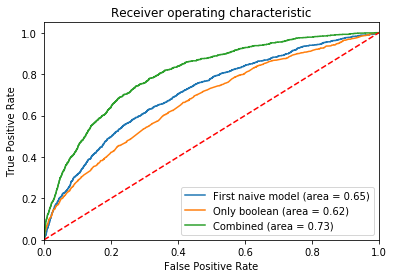

In [321]:
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label='First naive model (area = %0.2f)' % logit_roc_auc)


logit_roc_auc_2 = roc_auc_score(y_test_2, model2.predict(X_test_2))
fpr, tpr, thresholds = roc_curve(y_test, model2.predict_proba(X_test_2)[:,1])
plt.plot(fpr, tpr, label='Only boolean (area = %0.2f)' % logit_roc_auc_2)

logit_roc_auc_3 = roc_auc_score(y_test_3, model3.predict(X_test_3))
fpr, tpr, thresholds = roc_curve(y_test, model3.predict_proba(X_test_3)[:,1])
plt.plot(fpr, tpr, label='Combined (area = %0.2f)' % logit_roc_auc_3)

plt.plot([0, 1], [0, 1],'r--')



plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()